In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/0_raw_data/dataset.csv", index_col=0)

# Shape

In [3]:
df.shape

(114000, 20)

114,000 songs, 20 features per song

# dtypes

In [4]:
df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Most of the audio descriptors are either floats or integers. The artist, track name, album name, and genre are strings, as expected. There also is a boolean "explicit" attribute.

# Sample Rows

In [5]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


This matches our expectations formed from datatypes and column names

Note specifically how all float columns range from 0-1

# Check for missing data

In [6]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

There is one song that has null values for artists, album name, and track name. Let's identify where this occurs.

In [7]:
rows_with_missing_values = df[df.isnull().any(axis=1)]
rows_with_missing_values

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Given that the popularity and duration are both 0 in addition to the missing artist, album name, and track name information, this is more than likely an error with the dataset that can be safely removed.

In [8]:
df = df.drop(index=65900)
rows_with_missing_values = df[df.isnull().any(axis=1)]
rows_with_missing_values

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


The missing entry has been deleted

# Check for duplicate data

In [9]:
# Check duplicate rows
duplicate_rows = df[df.duplicated()]
duplicate_rows

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


There are 450 duplicate rows. Let's see how many duplicates there are for the tracks, to see if there are some tracks being duplicated many times or just a few duplicates for each track

In [10]:
# See how many duplicate row sets there are
duplicate_row_counts = df[df.duplicated(keep=False)].groupby(list(df.columns)).size().reset_index(name='count')
duplicate_row_counts['count'].unique()

array([2, 3])

No track has more than 3 duplicates. There likely isn't some underlying trend to be maintained and it is a simple error, so we can remove these duplicates.

In [11]:
# Remove all duplicates
df = df.drop_duplicates()
duplicate_rows = df[df.duplicated()]
duplicate_rows

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


All duplicates have been successfully removed

# Numeric Summaries

Specify which columns we wish to collect summary statistics for

In [12]:
df['duration_min'] = df['duration_ms'] / 60000

In [13]:
numeric_columns = ['popularity','duration_ms','duration_min','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']

Calculate the mean, std, min, max, and quantiles for everything in numeric_columns

In [14]:
df[numeric_columns].describe()

,popularity,duration_ms,duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,3.801356,0.567031,0.642091,-8.243408,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745
std,22.283855,1.064131e+05,1.773552,0.173409,0.251053,5.011422,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954
min,0.000000,8.586000e+03,0.143100,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,2.903067,0.456000,0.473000,-9.998000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000
50%,35.000000,2.130000e+05,3.550000,0.580000,0.685000,-6.997000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000
75%,50.000000,2.615880e+05,4.359800,0.695000,0.854000,-5.001000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000
max,100.000000,5.237295e+06,87.288250,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


Some gathered insights from this:
- The mean and median track length is 3.8 minutes and 3.5 minutes, respectively, but the longest track is 87 minutes long!
- Many of the float audio features are right skewed with many entries close to or at 0 but just a few close to or at 1 (see "instrumentalness" and "speechiness" for good examples)
- Average tempo (in BPM) for songs is around 122 for both mean and median, with the slowest song being 0 BPM (which could be analyzed as an outlier) and the fastest song being 243 BPM

Let's act on one of these insights, analyzing where the tempo was 0 BPM and if that makes sense

In [15]:
# Check where tempo is 0
zero_tempo_rows = df[df['tempo'] == 0]
zero_tempo_rows

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,Voyager - Essential Max Richter,The Departure,64,151506,False,0.0,0.03620,0,...,0,0.0,0.994000,0.940,0.0958,0.0,0.0,0,ambient,2.525100
4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,Jane Eyre - Original Motion Picture Soundtrack,The End of Childhood (feat. Jack Liebeck),55,73266,False,0.0,0.04450,0,...,0,0.0,0.972000,0.972,0.0873,0.0,0.0,0,ambient,1.221100
4664,1Kb2DqjHRvOcT5xeWtz3t5,Sylvain Chauveau,Des Plumes Dans La Tête,Ferme Les Yeux,53,68493,False,0.0,0.03230,2,...,0,0.0,0.994000,0.973,0.0922,0.0,0.0,0,ambient,1.141550
45670,6B9Mgf9smWqxDjA35VD6MK,Little Symphony,Rialto Beach,Campomoro,22,148711,False,0.0,0.00108,0,...,1,0.0,0.952000,0.991,0.2420,0.0,0.0,0,guitar,2.478517
45720,7i5OoyPXtSrqz9jobJfG1F,Little Symphony,Rialto Beach,Ritornello,23,102000,False,0.0,0.00129,7,...,1,0.0,0.969000,0.956,0.1230,0.0,0.0,0,guitar,1.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101988,5gEKRH0MCSegG8ZISUPaU2,Granular,The World Of,Tin White Noise,32,182050,False,0.0,0.00002,1,...,1,0.0,0.003850,0.903,0.9210,0.0,0.0,0,sleep,3.034167
101993,6H0kAiSAFB84jX7dgEDWd6,Rain Sounds,Rain,Rain: Natural Recording,32,84219,False,0.0,0.02540,8,...,1,0.0,0.000002,0.838,0.3390,0.0,0.0,0,sleep,1.403650
113428,5EYzrykQ95uOmepteDi9KT,El Ruido Blanco;Soñoliento Juan;Mantra para Do...,Aire Acondicionado de Ruido Blanco,Aire de verano,27,128000,False,0.0,0.18800,8,...,0,0.0,0.139000,0.339,0.1220,0.0,0.0,0,world-music,2.133333
113688,2EnZf7wbFv7ST4CJ3EvNzT,El Ruido Blanco,Ruido Blanco para el bebé: sonidos relajantes ...,Ruido Rosa Puro - Una Hora Versión,24,3601693,False,0.0,0.00002,1,...,1,0.0,0.186000,1.000,0.3620,0.0,0.0,0,world-music,60.028217


Let's see if there are some genres which more frequently have a tempo of 0 than others.

In [16]:
genre_counts = zero_tempo_rows['track_genre'].value_counts()
print(genre_counts)

track_genre
sleep          138
iranian          4
guitar           4
ambient          3
world-music      3
opera            2
jazz             1
show-tunes       1
romance          1
Name: count, dtype: int64


We can see that some of these tracks with a tempo of 0 are white noise (whose genre is typically categorized as "sleep"), so it makes sense that they wouldn't have a tempo. Others, however, including sountracks and guitar music, should have a listed tempo.

Unfortunately, there is no easy way to distinguish between white noise, since some of the genre distinctions are not clear (several of the tracks under "world-music" are actually better described as "ambient" or "sleep", for example).

Due to this lack of clear distinction, they will be left in the dataset for now. However, should the overall hypothesis and objective in the future focus on specifically songs rather than including ambient tracks, then it would be reasonable to delete all tracks with a tempo of 0.

This is something to note for later as potentially actionable, but for now, we will continue analyzing the overall data.

Let's act on another insight, looking at the shortest tracks to see if it makes sense for them to have such a low duration

In [17]:
# Return 10 rows with the shortest duration
shortest_duration_rows = df.nsmallest(10, 'duration_min')
shortest_duration_rows

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
59310,6hsyfegVY5yklJneM40mWi,Leila Bela,Angra Manyu,The Exorsism Begins...,0,8586,False,0.000,0.0400,8,...,0,0.0000,0.928,0.9560,0.115,0.000,0.000,0,iranian,0.143100
59812,38Ogh3rsHba83kXx13gbKs,Leila Bela,Angra Manyu,V-4,0,13386,False,0.000,0.2240,11,...,1,0.0000,0.970,0.0000,0.907,0.000,0.000,0,iranian,0.223100
59775,1HVjSh7scH1PaPiLjy2LEu,Leila Bela;Leila's Opera Class,Angra Manyu,Screams for a Finale! (feat. Leila's Opera Class),0,15800,False,0.251,0.5080,5,...,0,0.3160,0.969,0.9990,0.952,0.000,184.051,3,iranian,0.263333
16856,5YKCM3jbJ8lqUXUwfU7KwZ,Wolfgang Amadeus Mozart;Ingrid Haebler,Mozart: The Complete Piano Sonatas,"Andante in C Major, K. 1a",0,17453,False,0.467,0.0301,2,...,0,0.0428,0.995,0.9000,0.124,0.000,84.375,4,classical,0.290883
16288,1T5QvLF9lO4HO3OZQbaX9p,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,...,1,0.0370,0.985,0.9210,0.164,0.912,89.032,1,classical,0.297100
39233,1T5QvLF9lO4HO3OZQbaX9p,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,...,1,0.0370,0.985,0.9210,0.164,0.912,89.032,1,german,0.297100
59306,3qSaeaXmtOuzkqe7DKgoiM,Leila Bela,Angra Manyu,V-7,0,21120,False,0.229,0.0577,8,...,0,0.1960,0.626,0.9310,0.108,0.253,172.897,4,iranian,0.352000
59609,1oVrTBrCsM2eTE1G50yxY9,Leila Bela,Angra Manyu,Shatter,0,21240,False,0.424,0.8690,9,...,0,0.0728,0.707,0.0893,0.117,0.000,135.107,4,iranian,0.354000
11398,1egJZfc8JBT2blFQ4clPKe,Benjamin Britten;Steven Isserlis,October Classical Playlist,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",0,22266,False,0.335,0.0593,11,...,0,0.0430,0.992,0.8690,0.116,0.195,77.266,5,british,0.371100
16292,5viwzFJxwRE1OEUR7G6hiD,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 13, Estrella (Live in Jap...",0,23506,False,0.379,0.2370,5,...,1,0.0470,0.993,0.8870,0.144,0.477,116.093,4,classical,0.391767


Many of these incredibly short tracks exist on "story-based" albums or are short instrumental pieces part of larger works. As such, these represent valid points of data, and should not be removed.

Let's look at the opposite end- the longest tracks

In [18]:
# Longest tracks
longest_duration_rows = df.nlargest(10, 'duration_min')
longest_duration_rows

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
73617,3Cnz3Bu9Wcw8p3kiBTXTxp,Tale Of Us,Unity (Voyage Mix),Unity (Voyage Mix) Pt. 1,35,5237295,False,0.6950,0.736,5,...,0,0.0374,0.00399,0.8600,0.0910,0.05090,124.001,4,minimal-techno,87.288250
10935,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Compiled And Mixed By Tim...,Crossing Wires 002 - Continuous DJ Mix,11,4789026,False,0.6970,0.632,1,...,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4,breakbeat,79.817100
24348,6wypxnAvmv5zYewUX3VFDd,Seth Troxler,Seth Troxler - The Lab 03,The Lab 03 - Continuous DJ Mix Part 1,8,4730302,False,0.6840,0.656,5,...,0,0.0633,0.01910,0.8480,0.1030,0.30100,123.180,4,detroit-techno,78.838367
73840,6JbQr97EMFD2D3Ek6gxgt1,Loco Dice,Amnesia Ibiza - Underground 10,Amnesia Ibiza Underground 10 DJ Mix,17,4563897,False,0.7830,0.728,10,...,0,0.0612,0.00158,0.8400,0.1580,0.18900,125.044,4,minimal-techno,76.064950
13344,3gFme8BdfTtFHxKmuTnSbj,Mark Farina,House of OM (DJ Mix),House of Om - Mark Farina - Continuous Mix,11,4447520,False,0.8610,0.805,11,...,0,0.0711,0.00548,0.5770,0.1350,0.54500,129.306,4,chicago-house,74.125333
13245,13hQAhg1owjTpTcI9xQc6c,Mark Farina,Live In Tokyo,Live In Tokyo - Continuous Mix,11,4339826,False,0.8060,0.582,1,...,1,0.0874,0.00830,0.2370,0.3280,0.68600,128.368,4,chicago-house,72.330433
13195,3se0UYprtkHthJEBuk1A5K,Mark Farina,Greenhouse Construction,Greenhouse Construction,12,4334721,False,0.8460,0.744,10,...,0,0.0611,0.00371,0.3350,0.3130,0.53200,125.434,4,chicago-house,72.245350
27926,6eTDnsdPlRUyrTHqFj3l7W,Lenzman;Dan Stezo,NQ State of Mind,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",15,4246206,True,0.5930,0.924,1,...,1,0.0899,0.00369,0.0221,0.5340,0.24200,173.938,4,drum-and-bass,70.770100
101390,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Sounds,Ocean Waves Sounds to Relax and Sleep,Ocean Waves Sounds,39,4120258,False,0.0797,0.995,1,...,1,0.0612,0.93200,0.5620,0.3100,0.00001,84.788,3,sleep,68.670967
45063,0PINNy1r5eEILOuHpnjl5d,Estas Tonne,Internal Flight (Remastered),Internal Flight (Remastered),47,3876276,False,0.3000,0.640,4,...,0,0.0367,0.94600,0.8930,0.0783,0.21200,159.624,4,guitar,64.604600


Many of these are full DJ mixes which are over an hour long, but as such, are also valid data points.

# Distributions

Generate histograms

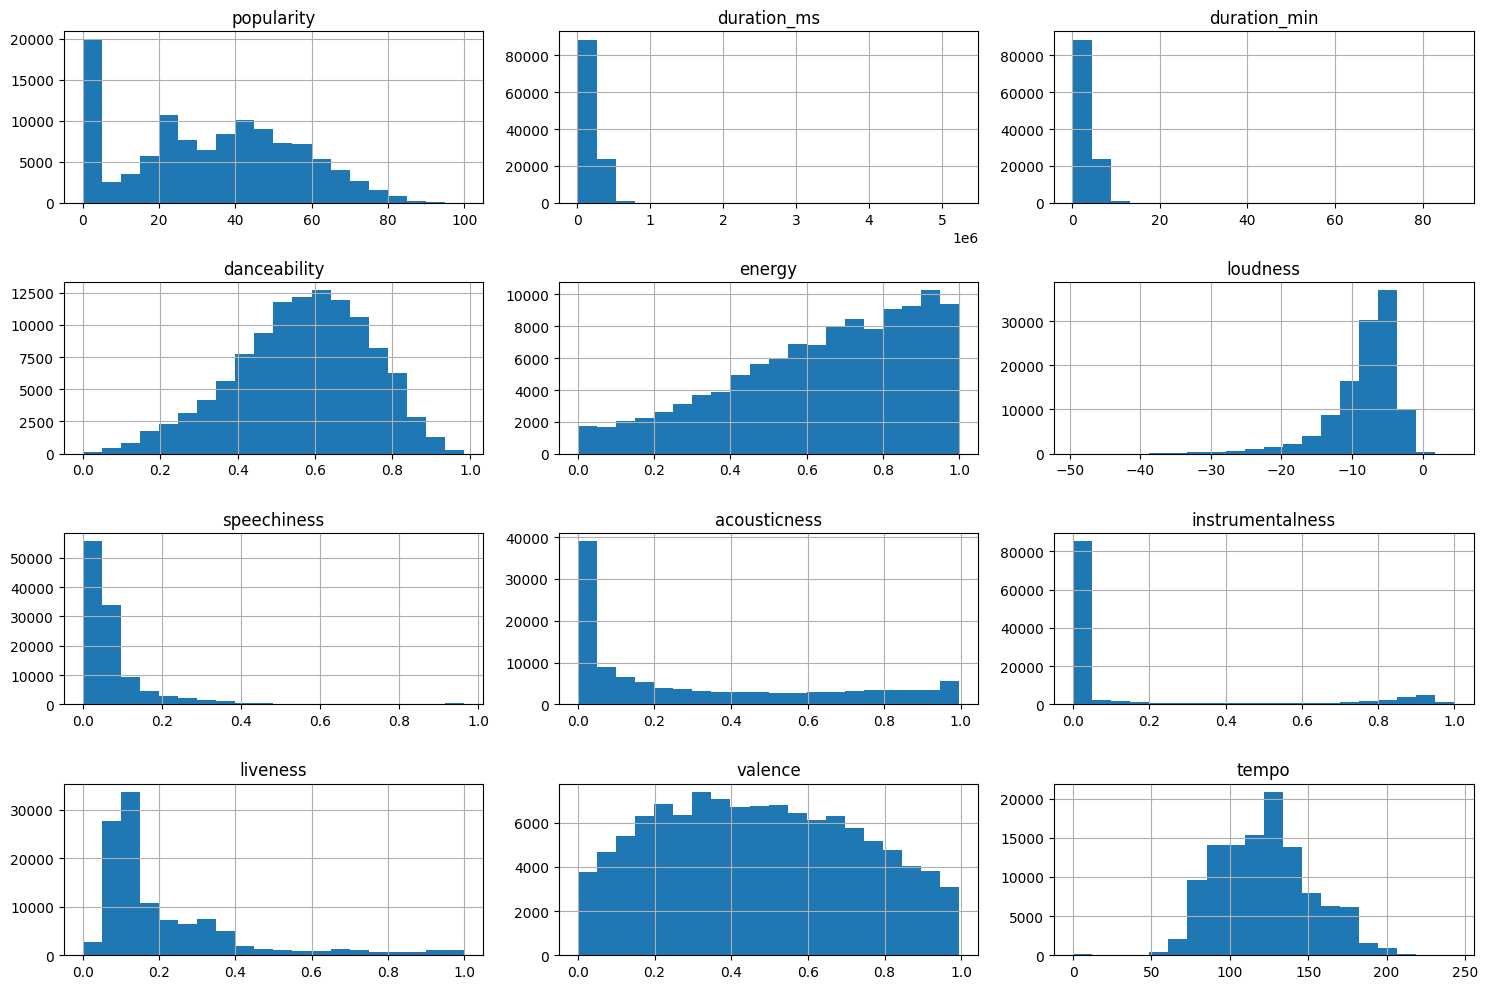

In [19]:
df[numeric_columns].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

## ***TODO: ADD HISTOGRAM INSIGHTS***

# Categorical Summaries

Specify which columns we wish to perform category analyses on

In [20]:
categorical_columns = ['explicit','key','mode','time_signature','track_genre']

Generate frequency tables

In [21]:
for col in categorical_columns:
    print(f"Frequency table for '{col}':")
    if col == 'track_genre':
        # Use to_string() so Jupyter doesn't truncate large Series output
        print(df[col].value_counts(dropna=False).to_string())
    else:
        print(df[col].value_counts(dropna=False))
    print("\n")

Frequency table for 'explicit':
explicit
False    103831
True       9718
Name: count, dtype: int64


Frequency table for 'key':
key
7     13199
0     13006
2     11594
9     11264
1     10740
5      9325
11     9251
4      8971
6      7891
10     7423
8      7337
3      3548
Name: count, dtype: int64


Frequency table for 'mode':
mode
1    72429
0    41120
Name: count, dtype: int64


Frequency table for 'time_signature':
time_signature
4    101486
3      9128
5      1805
1       967
0       163
Name: count, dtype: int64


Frequency table for 'track_genre':
track_genre
acoustic             1000
british              1000
electronic           1000
emo                  1000
funk                 1000
garage               1000
disco                1000
country              1000
rock                 1000
rock-n-roll          1000
sertanejo            1000
mandopop             1000
pagode               1000
mpb                  1000
metalcore            1000
j-rock               1000
industria

## ***TODO: ADD FREQUENCY INSIGHTS***

# Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix of Numeric Variables')

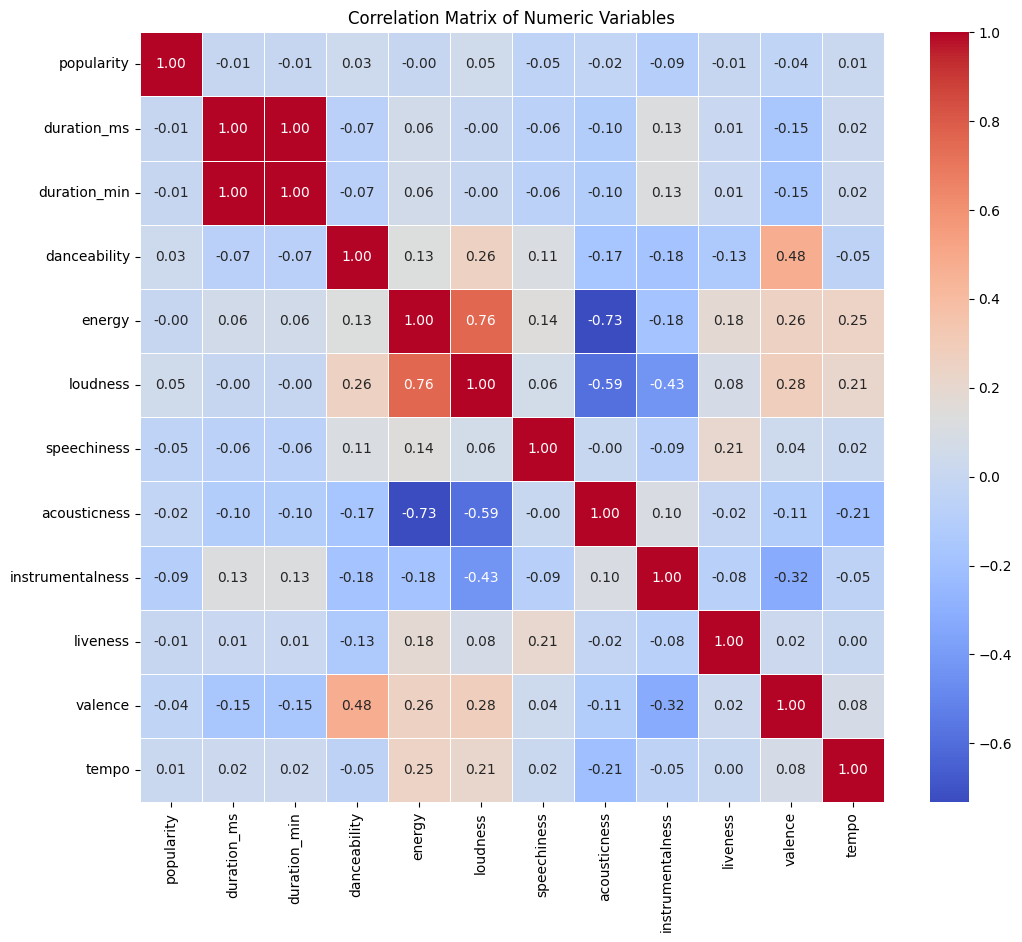

In [22]:
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")

## ***TODO: ADD INSIGHTS HERE***

Loudness vs Energy vs Acousticness (these three were most strongly correlated within the table above)

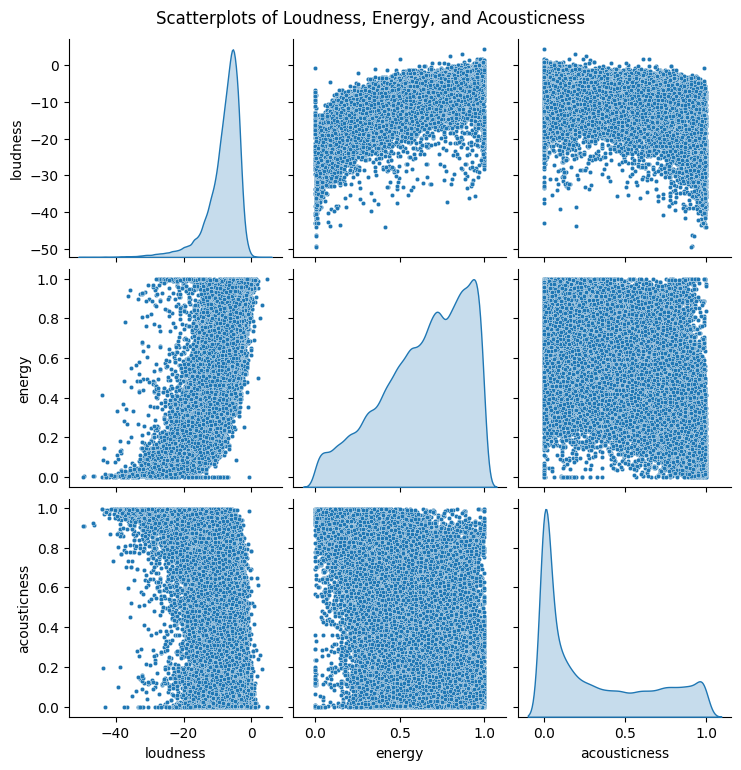

In [23]:
# Scatterplot of loudness vs energy, energy vs acousticness, and acousticness vs loudness (shrink the size of the points)
sns.pairplot(df, vars=['loudness', 'energy', 'acousticness'], plot_kws={'s': 10}, diag_kind='kde')
plt.suptitle("Scatterplots of Loudness, Energy, and Acousticness", y=1.02)
plt.show()

## ***TODO: ADD INSIGHT HERE***

# Outlier Identification

In [24]:
key_outlier_cols = ['duration_min','tempo']

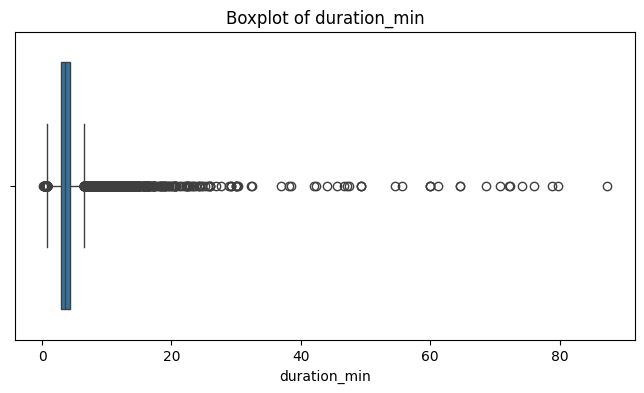

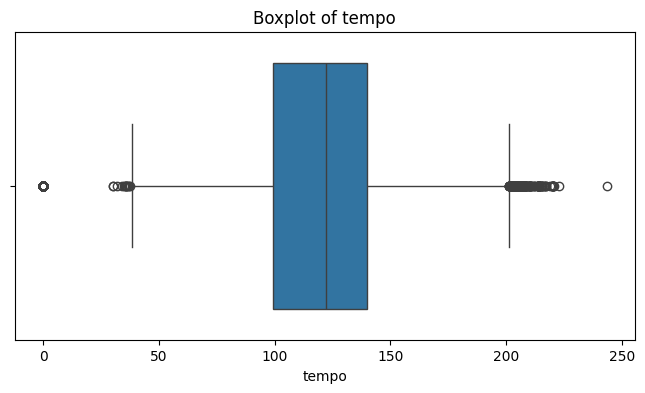

In [25]:
# Create boxplots for the key outlier columns
for col in key_outlier_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

As discussed above, despite there being outliers here, they typically are representative of some important detail present in the data (with the exception of some complicated 0 tempos). For now, we choose to maintain these outliers as part of the data.

# Save data with preprocessing changes

Since we made a few changes to the original, raw dataset, we will save this as a preprocessed (or at least, partially preprocessed) updated csv file

In [27]:
df.to_csv('data/1_preprocessed/preprocessed_dataset.csv', index=False)